In [224]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_ROOT = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data")
VOLUME_ROOT = DATA_ROOT / "volumes"
LABEL_ROOT = DATA_ROOT / "labels"

T11_LABEL = 18
T12_LABEL = 19
TARGET_LABELS = [T11_LABEL, T12_LABEL]
SOURCES = ["COLONOG", "COVID-19", "MSD-T10"]

In [225]:
high_risk_cases = pd.read_pickle("high_risk_cases.pkl")
small_z_cases = pd.read_pickle("small_z_cases.pkl")
edge_cases = pd.read_pickle("edge_cases.pkl")

In [226]:
print(high_risk_cases.head())
print(small_z_cases.head())
print(edge_cases.head())

        source                  patient_id                          file_name  \
306    COLONOG  1.3.6.1.4.1.9328.50.4.0163  1.3.6.1.4.1.9328.50.4.0163.nii.gz   
396    COLONOG  1.3.6.1.4.1.9328.50.4.0212  1.3.6.1.4.1.9328.50.4.0212.nii.gz   
604    COLONOG  1.3.6.1.4.1.9328.50.4.0327  1.3.6.1.4.1.9328.50.4.0327.nii.gz   
1583  COVID-19    volume-covid19-A-0106_ct    volume-covid19-A-0106_ct.nii.gz   
1593  COVID-19    volume-covid19-A-0187_ct    volume-covid19-A-0187_ct.nii.gz   

     label_name  label_value  voxel_count  \
306         T11           18          253   
396         T11           18            2   
604         T11           18          186   
1583        T12           19         8467   
1593        T12           19         5974   

                                             label_path            shape  \
306   C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...  (512, 512, 465)   
396   C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\...  (512, 512, 429)   
604   C:\Users

## 3개의 샘플을 하나로 합친 뒤 중복 제거

In [227]:
qa_candidates = pd.concat(
    [
        high_risk_cases,
        small_z_cases,
        edge_cases,
    ],
    ignore_index=True,
)

qa_candidates = (
    qa_candidates
    .drop_duplicates(["source", "patient_id", "file_name"])
    .copy()
)

qa_candidates = qa_candidates[
    [
        "source",
        "patient_id",
        "file_name",
        "bbox_z_size",
        "voxel_count",
        "distance_to_top",
        "distance_to_bottom",
    ]
].sort_values(["source", "file_name"])

display(qa_candidates.head())
print("QA candidate volumes:", len(qa_candidates))

,source,patient_id,file_name,bbox_z_size,voxel_count,distance_to_top,distance_to_bottom
18,COLONOG,1.3.6.1.4.1.9328.50.4.0006,1.3.6.1.4.1.9328.50.4.0006.nii.gz,47,99172,420,0
19,COLONOG,1.3.6.1.4.1.9328.50.4.0007,1.3.6.1.4.1.9328.50.4.0007.nii.gz,43,88945,458,0
20,COLONOG,1.3.6.1.4.1.9328.50.4.0017,1.3.6.1.4.1.9328.50.4.0017.nii.gz,51,112988,446,0
21,COLONOG,1.3.6.1.4.1.9328.50.4.0019,1.3.6.1.4.1.9328.50.4.0019.nii.gz,14,32294,430,0
23,COLONOG,1.3.6.1.4.1.9328.50.4.0024,1.3.6.1.4.1.9328.50.4.0024.nii.gz,54,76104,459,0


QA candidate volumes: 155


In [228]:
df_overlay_qa = qa_candidates.copy()

df_overlay_qa["qa_status"] = "unchecked"
df_overlay_qa["qa_note"] = ""

display(df_overlay_qa.head())

,source,patient_id,file_name,bbox_z_size,voxel_count,distance_to_top,distance_to_bottom,qa_status,qa_note
18,COLONOG,1.3.6.1.4.1.9328.50.4.0006,1.3.6.1.4.1.9328.50.4.0006.nii.gz,47,99172,420,0,unchecked,
19,COLONOG,1.3.6.1.4.1.9328.50.4.0007,1.3.6.1.4.1.9328.50.4.0007.nii.gz,43,88945,458,0,unchecked,
20,COLONOG,1.3.6.1.4.1.9328.50.4.0017,1.3.6.1.4.1.9328.50.4.0017.nii.gz,51,112988,446,0,unchecked,
21,COLONOG,1.3.6.1.4.1.9328.50.4.0019,1.3.6.1.4.1.9328.50.4.0019.nii.gz,14,32294,430,0,unchecked,
23,COLONOG,1.3.6.1.4.1.9328.50.4.0024,1.3.6.1.4.1.9328.50.4.0024.nii.gz,54,76104,459,0,unchecked,


In [229]:
df_overlay_qa.to_csv(
    "t11_t12_overlay_qa.csv",
    index=False,
    encoding="utf-8-sig",
)

# t11_t12_overlay_qa.csv에서 volume 하나씩 세 방향으로 확인하여 학습 데이터 선별

In [230]:
csv_path = Path(r"C:\Users\comds\Desktop\졸업작품\vscode_script\t11_t12_overlay_qa.csv")

df_overlay_qa = pd.read_csv(csv_path, encoding="utf-8-sig")
df_overlay_qa.columns = df_overlay_qa.columns.str.strip()

print(df_overlay_qa.columns.tolist())
display(df_overlay_qa.head())

['source', 'patient_id', 'file_name', 'bbox_z_size', 'voxel_count', 'distance_to_top', 'distance_to_bottom', 'qa_status', 'qa_note']


,source,patient_id,file_name,bbox_z_size,voxel_count,distance_to_top,distance_to_bottom,qa_status,qa_note
0,COLONOG,1.3.6.1.4.1.9328.50.4.0006,1.3.6.1.4.1.9328.50.4.0006.nii.gz,47,99172,420,0,unchecked,NaN
1,COLONOG,1.3.6.1.4.1.9328.50.4.0007,1.3.6.1.4.1.9328.50.4.0007.nii.gz,43,88945,458,0,unchecked,NaN
2,COLONOG,1.3.6.1.4.1.9328.50.4.0017,1.3.6.1.4.1.9328.50.4.0017.nii.gz,51,112988,446,0,unchecked,NaN
3,COLONOG,1.3.6.1.4.1.9328.50.4.0019,1.3.6.1.4.1.9328.50.4.0019.nii.gz,14,32294,430,0,unchecked,NaN
4,COLONOG,1.3.6.1.4.1.9328.50.4.0024,1.3.6.1.4.1.9328.50.4.0024.nii.gz,54,76104,459,0,unchecked,NaN


In [231]:
def get_volume_path(source, file_name):
    return VOLUME_ROOT / source / file_name


def find_label_path(volume_path):
    rel = volume_path.relative_to(VOLUME_ROOT)
    label_dir = LABEL_ROOT / rel.parent
    stem = volume_path.name.replace(".nii.gz", "")

    candidates = [
        label_dir / f"{stem}_seg.nii.gz",
        label_dir / volume_path.name,
        label_dir / f"{stem}.nii.gz",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


def apply_hu_window(image, lower=-1000, upper=2000):
    image = np.clip(image, lower, upper)
    image = (image - lower) / (upper - lower)
    return image

In [232]:
def show_one_volume_t11_t12(
    source,
    file_name,
    window=(-1000, 2000),
    crop=True,
    margin=40,
):
    volume_path = get_volume_path(source, file_name)
    label_path = find_label_path(volume_path)

    if label_path is None:
        print("Label not found:", file_name)
        return

    image = np.asanyarray(nib.load(volume_path).dataobj)
    seg = np.asanyarray(nib.load(label_path).dataobj)

    if image.shape != seg.shape:
        print("Shape mismatch")
        print("image shape:", image.shape)
        print("label shape:", seg.shape)
        return

    target_mask = np.isin(seg, [T11_LABEL, T12_LABEL])

    if not target_mask.any():
        print("T11/T12 not found:", file_name)
        return

    def get_label_bbox(label_value):
        mask = seg == label_value

        if not mask.any():
            return None

        coords = np.argwhere(mask)
        x_min, y_min, z_min = coords.min(axis=0)
        x_max, y_max, z_max = coords.max(axis=0)

        return {
            "x_min": int(x_min),
            "x_max": int(x_max),
            "y_min": int(y_min),
            "y_max": int(y_max),
            "z_min": int(z_min),
            "z_max": int(z_max),
            "x_center": int((x_min + x_max) / 2),
            "y_center": int((y_min + y_max) / 2),
            "z_center": int((z_min + z_max) / 2),
        }

    t11_bbox = get_label_bbox(T11_LABEL)
    t12_bbox = get_label_bbox(T12_LABEL)

    target_coords = np.argwhere(target_mask)
    x_min, y_min, z_min = target_coords.min(axis=0)
    x_max, y_max, z_max = target_coords.max(axis=0)

    x_min, y_min, z_min = int(x_min), int(y_min), int(z_min)
    x_max, y_max, z_max = int(x_max), int(y_max), int(z_max)

    x_center = int((x_min + x_max) / 2)
    y_center = int((y_min + y_max) / 2)
    z_center = int((z_min + z_max) / 2)

    if crop:
        x0 = max(0, x_min - margin)
        x1 = min(image.shape[0], x_max + margin + 1)
        y0 = max(0, y_min - margin)
        y1 = min(image.shape[1], y_max + margin + 1)
        z0 = max(0, z_min - margin)
        z1 = min(image.shape[2], z_max + margin + 1)
    else:
        x0, x1 = 0, image.shape[0]
        y0, y1 = 0, image.shape[1]
        z0, z1 = 0, image.shape[2]

    image_windowed = apply_hu_window(image, lower=window[0], upper=window[1])

    cmap = ListedColormap(["red", "cyan"])
    norm = BoundaryNorm([0.5, 1.5, 2.5], cmap.N)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    def draw_overlay(ax, img_slice, seg_slice, title):
        overlay = np.zeros_like(seg_slice, dtype=np.uint8)
        overlay[seg_slice == T11_LABEL] = 1
        overlay[seg_slice == T12_LABEL] = 2
        overlay = np.ma.masked_where(overlay == 0, overlay)

        ax.imshow(img_slice.T, cmap="gray", origin="lower", aspect="auto")
        ax.imshow(
            overlay.T,
            cmap=cmap,
            norm=norm,
            alpha=0.45,
            origin="lower",
            aspect="auto",
        )

        ax.set_title(title)
        ax.axis("off")

    # 1. T11 center axial
    if t11_bbox is not None:
        z_t11 = t11_bbox["z_center"]

        if crop:
            x0_t11 = max(0, t11_bbox["x_min"] - margin)
            x1_t11 = min(image.shape[0], t11_bbox["x_max"] + margin + 1)
            y0_t11 = max(0, t11_bbox["y_min"] - margin)
            y1_t11 = min(image.shape[1], t11_bbox["y_max"] + margin + 1)
        else:
            x0_t11, x1_t11 = 0, image.shape[0]
            y0_t11, y1_t11 = 0, image.shape[1]

        draw_overlay(
            axes[0],
            image_windowed[x0_t11:x1_t11, y0_t11:y1_t11, z_t11],
            seg[x0_t11:x1_t11, y0_t11:y1_t11, z_t11],
            f"T11 center axial\nz={z_t11}, range={t11_bbox['z_min']}-{t11_bbox['z_max']}",
        )
    else:
        axes[0].set_title("T11 not found")
        axes[0].axis("off")

    # 2. T12 center axial
    if t12_bbox is not None:
        z_t12 = t12_bbox["z_center"]

        if crop:
            x0_t12 = max(0, t12_bbox["x_min"] - margin)
            x1_t12 = min(image.shape[0], t12_bbox["x_max"] + margin + 1)
            y0_t12 = max(0, t12_bbox["y_min"] - margin)
            y1_t12 = min(image.shape[1], t12_bbox["y_max"] + margin + 1)
        else:
            x0_t12, x1_t12 = 0, image.shape[0]
            y0_t12, y1_t12 = 0, image.shape[1]

        draw_overlay(
            axes[1],
            image_windowed[x0_t12:x1_t12, y0_t12:y1_t12, z_t12],
            seg[x0_t12:x1_t12, y0_t12:y1_t12, z_t12],
            f"T12 center axial\nz={z_t12}, range={t12_bbox['z_min']}-{t12_bbox['z_max']}",
        )
    else:
        axes[1].set_title("T12 not found")
        axes[1].axis("off")

    # 3. Coronal center, x-z plane at y_center
    draw_overlay(
        axes[2],
        image_windowed[x0:x1, y_center, z0:z1],
        seg[x0:x1, y_center, z0:z1],
        f"Coronal center\ny={y_center}",
    )

    # 4. Sagittal center, y-z plane at x_center
    draw_overlay(
        axes[3],
        image_windowed[x_center, y0:y1, z0:z1],
        seg[x_center, y0:y1, z0:z1],
        f"Sagittal center\nx={x_center}",
    )

    plt.suptitle(
        f"{source} | {file_name}\n"
        f"T11/T12 bbox x:{x_min}-{x_max}, y:{y_min}-{y_max}, z:{z_min}-{z_max}",
        y=1.05,
    )
    plt.tight_layout()
    plt.show()

    print("volume_path:", volume_path)
    print("label_path:", label_path)
    print("shape:", image.shape)
    print("T11/T12 bbox:")
    print("x:", x_min, "-", x_max)
    print("y:", y_min, "-", y_max)
    print("z:", z_min, "-", z_max)

    if t11_bbox is not None:
        print("T11 z range:", t11_bbox["z_min"], "-", t11_bbox["z_max"])

    if t12_bbox is not None:
        print("T12 z range:", t12_bbox["z_min"], "-", t12_bbox["z_max"])

    print("red = T11, cyan = T12")

In [233]:
from matplotlib.colors import ListedColormap, BoundaryNorm
qa_candidates = qa_candidates.reset_index(drop=True)

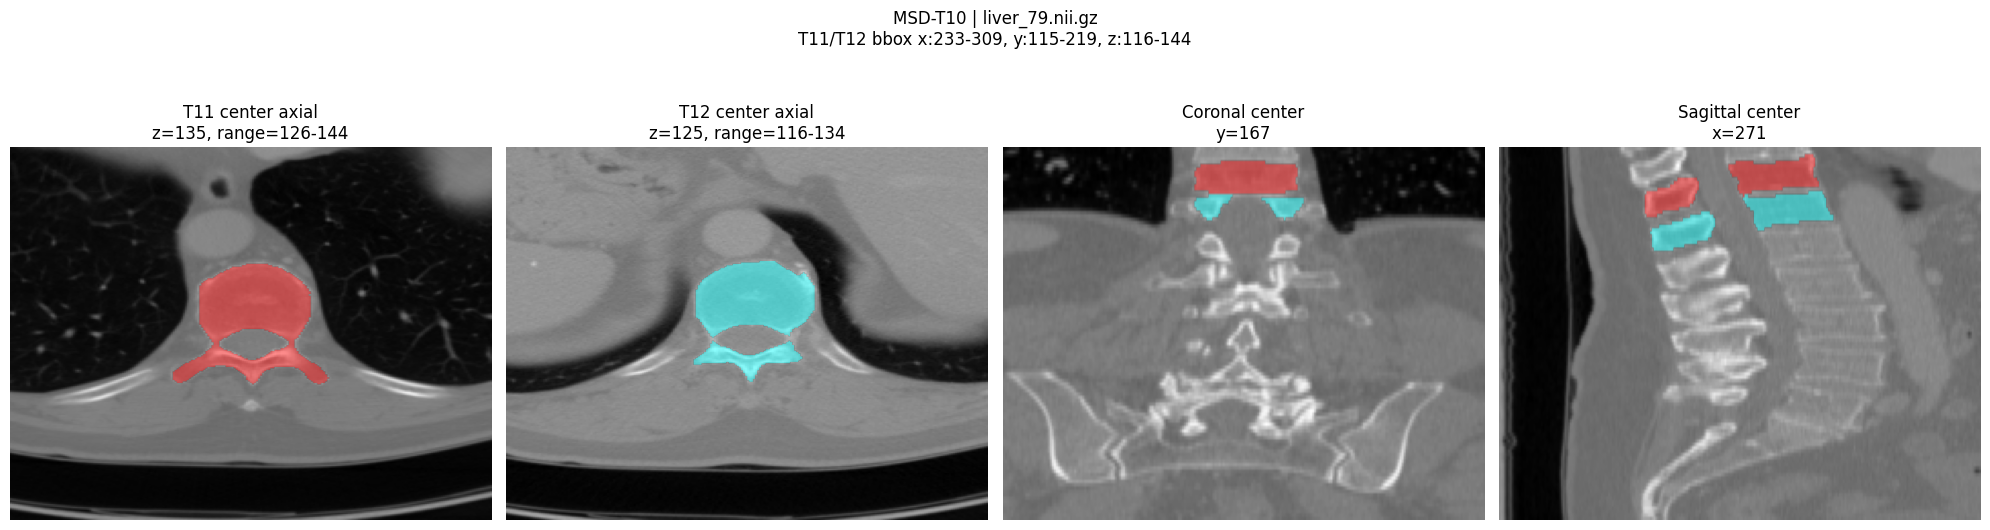

volume_path: C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\volumes\MSD-T10\liver_79.nii.gz
label_path: C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data\labels\MSD-T10\liver_79_seg.nii.gz
shape: (512, 512, 147)
T11/T12 bbox:
x: 233 - 309
y: 115 - 219
z: 116 - 144
T11 z range: 126 - 144
T12 z range: 116 - 134
red = T11, cyan = T12


In [325]:
i = 154

row = qa_candidates.iloc[i]

show_one_volume_t11_t12(
    source=row["source"],
    file_name=row["file_name"],
    crop=True,
    margin=80,
)

In [329]:
import pandas as pd
from pathlib import Path

qa_path = Path(r"C:\Users\comds\Desktop\졸업작품\vscode_script\t11_t12_overlay_qa_final.csv")

df_overlay_qa = pd.read_csv(qa_path, encoding="utf-8-sig")
df_overlay_qa.columns = df_overlay_qa.columns.str.strip()

display(df_overlay_qa["qa_status"].value_counts())
display(pd.crosstab(df_overlay_qa["source"], df_overlay_qa["qa_status"], margins=True))

qa_status
usable       110
partial       30
uncertain     15
Name: count, dtype: int64

qa_status,partial,uncertain,usable,All
source,,,,
COLONOG,28,9,91,128
COVID-19,2,3,12,17
MSD-T10,0,3,7,10
All,30,15,110,155


In [330]:
import pandas as pd

T11_LABEL = 18
T12_LABEL = 19

df_label_summary = pd.read_pickle("label_summary_by_volume.pkl")

df_t11_t12_check = df_label_summary.copy()

df_t11_t12_check["has_T11"] = df_t11_t12_check["label_values"].apply(
    lambda labels: T11_LABEL in labels
)

df_t11_t12_check["has_T12"] = df_t11_t12_check["label_values"].apply(
    lambda labels: T12_LABEL in labels
)

df_t11_t12_check["has_T11_T12"] = (
    df_t11_t12_check["has_T11"] &
    df_t11_t12_check["has_T12"]
)

df_t11_t12_candidates = df_t11_t12_check[
    df_t11_t12_check["has_T11_T12"]
].copy()

print("T11/T12 candidate volumes:", len(df_t11_t12_candidates))
display(df_t11_t12_candidates.groupby("source").size())

T11/T12 candidate volumes: 969


source
COLONOG     780
COVID-19     39
MSD-T10     150
dtype: int64

In [331]:
exclude_statuses = ["partial", "mismatch"]

exclude_keys = (
    df_overlay_qa[
        df_overlay_qa["qa_status"].isin(exclude_statuses)
    ][["source", "file_name"]]
    .drop_duplicates()
)

df_t11_t12_final = df_t11_t12_candidates.merge(
    exclude_keys.assign(exclude_by_overlay_qa=True),
    on=["source", "file_name"],
    how="left",
)

df_t11_t12_final["exclude_by_overlay_qa"] = (
    df_t11_t12_final["exclude_by_overlay_qa"]
    .fillna(False)
    .astype(bool)
)

df_t11_t12_final = df_t11_t12_final[
    df_t11_t12_final["exclude_by_overlay_qa"] == False
].copy()

print("Before QA exclusion:", len(df_t11_t12_candidates))
print("Excluded:", len(exclude_keys))
print("After QA exclusion:", len(df_t11_t12_final))

display(
    df_t11_t12_final
    .groupby("source")
    .size()
    .rename("n_final_volumes")
    .to_frame()
)

Before QA exclusion: 969
Excluded: 30
After QA exclusion: 939


,n_final_volumes
source,
COLONOG,752
COVID-19,37
MSD-T10,150


In [332]:
df_t11_t12_final.to_pickle("df_t11_t12_final_candidates.pkl")

df_t11_t12_final.to_csv(
    "df_t11_t12_final_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)

In [333]:
display(
    df_t11_t12_final
    .groupby("source")
    .size()
    .rename("n_final_volumes")
    .to_frame()
)

,n_final_volumes
source,
COLONOG,752
COVID-19,37
MSD-T10,150
